# Modelos LSTM y similitud catch22 — Movimiento de Viajeros

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import copy

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cpu')

## 1. Carga y preparación de datos

In [2]:
def cargar_csv_robusto(path):
    intentos = [
        {"encoding": "utf-8-sig", "sep": ","},
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "latin-1", "sep": ","},
        {"encoding": "cp1252", "sep": ","},
    ]
    for params in intentos:
        try:
            df_test = pd.read_csv(path, **params, nrows=50)
            cols_ok = any("ñ" in c or "í" in c or "ó" in c for c in df_test.columns)
            texto_roto = any("M-CM-" in c or "AM-CM" in c for c in df_test.columns)
            if cols_ok and not texto_roto:
                return pd.read_csv(path, **params)
        except Exception:
            continue

    df_raw = pd.read_csv(path, encoding="latin-1", sep=",")

    def fix_text(x):
        if isinstance(x, str):
            try:
                return x.encode("latin-1").decode("utf-8")
            except (UnicodeDecodeError, UnicodeEncodeError):
                return x
        return x

    df_raw.columns = [fix_text(c) for c in df_raw.columns]
    for col in df_raw.select_dtypes(include="object").columns:
        df_raw[col] = df_raw[col].apply(fix_text)
    return df_raw


df = cargar_csv_robusto("../data/raw/Base_Migracion_2009-2026jun.csv")
df.columns = [c.strip() for c in df.columns]

rename_map = {
    "AM-CM-1o": "Año", "Mes cod": "Mes_cod", "VM-CM--a": "Vía",
    "PaM-CM--s": "País", "RegiM-CM-3n": "Región", "RegiM-CM-3n dos": "Región_dos",
    "AgrupaciM-CM-3n Residencia": "Agrupación_Residencia", "Tipo de Viajero": "Tipo_Viajero",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

df["Año"] = pd.to_numeric(df["Año"], errors="coerce").astype("Int64")
df["Mes_cod"] = pd.to_numeric(df["Mes_cod"], errors="coerce").astype("Int64")
df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes_cod"], day=1), errors="coerce")
df = df.dropna(subset=["Fecha", "Viajero"])

df.head()


,Año,Mes_cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo_Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


## 2. Series de tiempo y partición entrenamiento/prueba (idénticas al Laboratorio 1)

Ejercicio 1.1: se reutilizan **exactamente** la misma partición 70 % / 30 % (por posición temporal)
y las mismas 8 series construidas en el Laboratorio 1 (serie total obligatoria + Top 3 países de
residencia + los 4 tipos de viajero), para que la comparación del punto 1.4 sea válida.

In [3]:
serie_total_full = df.groupby("Fecha")["Viajero"].sum().sort_index()

# Partición 70/30 por posición, igual que en el Laboratorio 1 (sección 7 del EDA)
train_len = int(0.7 * len(serie_total_full))
train_end_date = serie_total_full.index[train_len - 1]
test_start_date = serie_total_full.index[train_len]

print(f"Serie total: {len(serie_total_full)} meses "
      f"({serie_total_full.index.min().date()} a {serie_total_full.index.max().date()})")
print(f"Entrenamiento: hasta {train_end_date.date()} ({train_len} meses, "
      f"{train_len/len(serie_total_full):.1%})")
print(f"Prueba: desde {test_start_date.date()} "
      f"({len(serie_total_full) - train_len} meses, "
      f"{(len(serie_total_full)-train_len)/len(serie_total_full):.1%})")

df_train = df[df["Fecha"] <= train_end_date].copy()

# Mismas categorías seleccionadas en el Laboratorio 1: Top 3 países (por volumen en entrenamiento)
# y todos los tipos de viajero
paises_top3 = df_train.groupby("País")["Viajero"].sum().sort_values(ascending=False).head(3).index.tolist()
tipos_viajero = df_train["Tipo_Viajero"].unique().tolist()
print("Top 3 países:", paises_top3)
print("Tipos de viajero:", tipos_viajero)

full_range = pd.date_range(serie_total_full.index.min(), serie_total_full.index.max(), freq="MS")


def serie_mensual(mask):
    return df[mask].groupby("Fecha")["Viajero"].sum().reindex(full_range, fill_value=0.0)


SERIES_FULL = {"Total internacionales": serie_total_full.reindex(full_range, fill_value=0.0)}
for pais in paises_top3:
    SERIES_FULL[f"País: {pais}"] = serie_mensual(df["País"] == pais)
for tipo in tipos_viajero:
    SERIES_FULL[f"Tipo: {tipo}"] = serie_mensual(df["Tipo_Viajero"] == tipo)

SPLIT_IDX = train_len  # mismo índice de corte (147) para todas las series, todas comparten full_range

# Series restringidas al período de entrenamiento — son las que el Laboratorio 1 usó para
# EDA/ACF/descomposición y las que se emplean aquí para catch22 (Ejercicio 2)
SERIES_TRAIN = {name: s.iloc[:SPLIT_IDX] for name, s in SERIES_FULL.items()}

resumen_series = pd.DataFrame([
    {"Serie": nombre, "Inicio": s.index.min().date(), "Fin": s.index.max().date(),
     "Frecuencia": pd.infer_freq(s.index), "N_obs": len(s)}
    for nombre, s in SERIES_TRAIN.items()
])
resumen_series


Serie total: 210 meses (2009-01-01 a 2026-06-01)
Entrenamiento: hasta 2021-03-01 (147 meses, 70.0%)
Prueba: desde 2021-04-01 (63 meses, 30.0%)
Top 3 países: ['Guatemala', 'El Salvador', 'Estados Unidos de América']
Tipos de viajero: ['Turista', 'Cruceristas', 'Viajero', 'Excursionista']


,Serie,Inicio,Fin,Frecuencia,N_obs
0,Total internacionales,2009-01-01,2021-03-01,MS,147
1,País: Guatemala,2009-01-01,2021-03-01,MS,147
2,País: El Salvador,2009-01-01,2021-03-01,MS,147
3,País: Estados Unidos de América,2009-01-01,2021-03-01,MS,147
4,Tipo: Turista,2009-01-01,2021-03-01,MS,147
5,Tipo: Cruceristas,2009-01-01,2021-03-01,MS,147
6,Tipo: Viajero,2009-01-01,2021-03-01,MS,147
7,Tipo: Excursionista,2009-01-01,2021-03-01,MS,147


**Ejercicio 1.1 — Series elegidas para los modelos LSTM.** De las 8 series anteriores se seleccionan
dos con dinámicas distintas para el Ejercicio 1: **"Total internacionales"** (serie obligatoria, la de
mayor volumen y en la que el mejor modelo del Laboratorio 1 fue Prophet) y **"Tipo: Turista"**
(la categoría de mayor peso dentro de tipo de viajero, en la que el mejor modelo del Laboratorio 1 fue
ARIMA). Para ambas se usa el mismo `SPLIT_IDX` (147 meses de entrenamiento / 63 de prueba) que en el
Laboratorio 1.

In [4]:
SERIES_LSTM = {
    "Total internacionales": SERIES_FULL["Total internacionales"],
    "Tipo: Turista": SERIES_FULL["Tipo: Turista"],
}

for nombre, s in SERIES_LSTM.items():
    print(f"{nombre}: entrenamiento {s.iloc[:SPLIT_IDX].index.min().date()} a "
          f"{s.iloc[:SPLIT_IDX].index.max().date()} | prueba {s.iloc[SPLIT_IDX:].index.min().date()} a "
          f"{s.iloc[SPLIT_IDX:].index.max().date()}")


Total internacionales: entrenamiento 2009-01-01 a 2021-03-01 | prueba 2021-04-01 a 2026-06-01
Tipo: Turista: entrenamiento 2009-01-01 a 2021-03-01 | prueba 2021-04-01 a 2026-06-01


## 3. Utilidades: ventanas, split y escalado

In [5]:
WINDOW_GRID = [6, 12]

def create_sequences(values, window_size):
    X, y = [], []
    for i in range(len(values) - window_size):
        X.append(values[i:i + window_size])
        y.append(values[i + window_size])
    return np.array(X), np.array(y)


def prepare_series(values, window_size, split_idx):
    """Escala con MinMax (ajustado solo en entrenamiento) y arma ventanas deslizantes.
    `split_idx` es el índice de corte fijo (147, igual que en el Laboratorio 1), no un ratio."""
    n = len(values)
    scaler = MinMaxScaler()
    scaler.fit(values[:split_idx].reshape(-1, 1))
    scaled = scaler.transform(values.reshape(-1, 1)).flatten()

    X, y = create_sequences(scaled, window_size)
    target_idx = np.arange(window_size, n)
    train_mask = target_idx < split_idx

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[~train_mask], y[~train_mask]
    return X_train[..., None], y_train, X_test[..., None], y_test, scaler


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 4. LSTM

In [6]:
class LSTMSimple(nn.Module):
    def __init__(self, units=32, **kwargs):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=units, batch_first=True)
        self.fc = nn.Linear(units, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class LSTMStacked(nn.Module):
    def __init__(self, units=32, dropout=0.2, **kwargs):
        super().__init__()
        units2 = max(units // 2, 4)
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=units, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(input_size=units, hidden_size=units2, batch_first=True)
        self.fc = nn.Linear(units2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop(out)
        out, _ = self.lstm2(out)
        return self.fc(out[:, -1, :])


PARAM_GRID = [
    {"window_size": 6, "units": 16, "dropout": 0.1, "lr": 1e-3},
    {"window_size": 12, "units": 32, "dropout": 0.2, "lr": 1e-3},
    {"window_size": 12, "units": 64, "dropout": 0.3, "lr": 5e-4},
]

ARCHITECTURES = {
    "LSTM_simple": LSTMSimple,
    "LSTM_stacked": LSTMStacked,
}


## 5. Tuneo de hiperparámetros y entrenamiento por serie

Ejercicio 1.2: por cada una de las 2 series se entrenan **6 configuraciones** (2 arquitecturas ×
3 combinaciones de `window_size`/`units`/`dropout`/`lr`), es decir muchas más de las 2 configuraciones
mínimas pedidas. El mejor modelo de cada serie se elige por el RMSE de validación (85/15 dentro del
tramo de entrenamiento, sin tocar el conjunto de prueba).

In [7]:
def train_torch_model(model, X_tr, y_tr, X_val, y_val, lr, epochs=100, batch_size=16, patience=8):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val).to(DEVICE)
    y_val_t = torch.tensor(y_val).to(DEVICE)

    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb).squeeze(-1)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze(-1)
            val_loss = loss_fn(val_pred, y_val_t).item()

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val


def tune_series(name, series, split_idx, epochs=100, batch_size=16, patience=8):
    values = series.values.astype("float32")
    trials = []

    for arch_name, model_cls in ARCHITECTURES.items():
        for params in PARAM_GRID:
            ws = params["window_size"]
            X_train, y_train, X_test, y_test, scaler = prepare_series(values, ws, split_idx)
            if len(X_train) < 20 or len(X_test) < 4:
                continue

            val_split = int(len(X_train) * 0.85)
            X_tr, y_tr = X_train[:val_split], y_train[:val_split]
            X_val, y_val = X_train[val_split:], y_train[val_split:]

            torch.manual_seed(SEED)
            kwargs = dict(units=params["units"])
            if arch_name == "LSTM_stacked":
                kwargs["dropout"] = params["dropout"]
            model = model_cls(**kwargs)

            model, val_rmse_scaled = train_torch_model(
                model, X_tr, y_tr, X_val, y_val, lr=params["lr"],
                epochs=epochs, batch_size=batch_size, patience=patience,
            )
            val_rmse_scaled = float(np.sqrt(val_rmse_scaled))

            trials.append({
                "serie": name, "arch": arch_name, **params,
                "val_rmse_scaled": val_rmse_scaled,
                "model": model, "scaler": scaler,
                "X_test": X_test, "y_test": y_test,
            })

    if not trials:
        return None, None

    best = min(trials, key=lambda t: t["val_rmse_scaled"])
    trials_df = pd.DataFrame(trials).drop(columns=["model", "scaler", "X_test", "y_test"])
    return best, trials_df


all_trials = []
best_per_series = {}

for name, series in SERIES_LSTM.items():
    best, trials_df = tune_series(name, series, SPLIT_IDX)
    if best is None:
        continue
    best_per_series[name] = best
    all_trials.append(trials_df)

trials_summary = pd.concat(all_trials, ignore_index=True)
trials_summary.sort_values(["serie", "val_rmse_scaled"])


,serie,arch,window_size,units,dropout,lr,val_rmse_scaled
7,Tipo: Turista,LSTM_simple,12,32,0.2,0.0010,0.296991
6,Tipo: Turista,LSTM_simple,6,16,0.1,0.0010,0.304376
8,Tipo: Turista,LSTM_simple,12,64,0.3,0.0005,0.311769
9,Tipo: Turista,LSTM_stacked,6,16,0.1,0.0010,0.326046
10,Tipo: Turista,LSTM_stacked,12,32,0.2,0.0010,0.332062
11,Tipo: Turista,LSTM_stacked,12,64,0.3,0.0005,0.339124
0,Total internacionales,LSTM_simple,6,16,0.1,0.0010,0.268504
1,Total internacionales,LSTM_simple,12,32,0.2,0.0010,0.322799
2,Total internacionales,LSTM_simple,12,64,0.3,0.0005,0.336903
5,Total internacionales,LSTM_stacked,12,64,0.3,0.0005,0.348954


## 6. Evaluación en test del mejor modelo por serie (Ejercicio 1.3)

In [8]:
def evaluate_best(best):
    model, scaler = best["model"], best["scaler"]
    X_test, y_test = best["X_test"], best["y_test"]

    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(torch.tensor(X_test).to(DEVICE)).squeeze(-1).cpu().numpy()

    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_orig = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    return {
        "serie": best["serie"],
        "arch": best["arch"],
        "window_size": best["window_size"],
        "units": best["units"],
        "lr": best["lr"],
        "RMSE": rmse(y_test_orig, y_pred_orig),
        "MAE": mean_absolute_error(y_test_orig, y_pred_orig),
        "MAPE": mean_absolute_percentage_error(y_test_orig, y_pred_orig),
        "y_test": y_test_orig,
        "y_pred": y_pred_orig,
    }


eval_results = {name: evaluate_best(best) for name, best in best_per_series.items()}

metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_test", "y_pred")}
    for r in eval_results.values()
]).sort_values("RMSE")

metrics_df


,serie,arch,window_size,units,lr,RMSE,MAE,MAPE
0,Total internacionales,LSTM_simple,6,16,0.001,65423.93348,53203.089844,0.232357
1,Tipo: Turista,LSTM_simple,12,32,0.001,70556.26294,61550.820312,0.331049


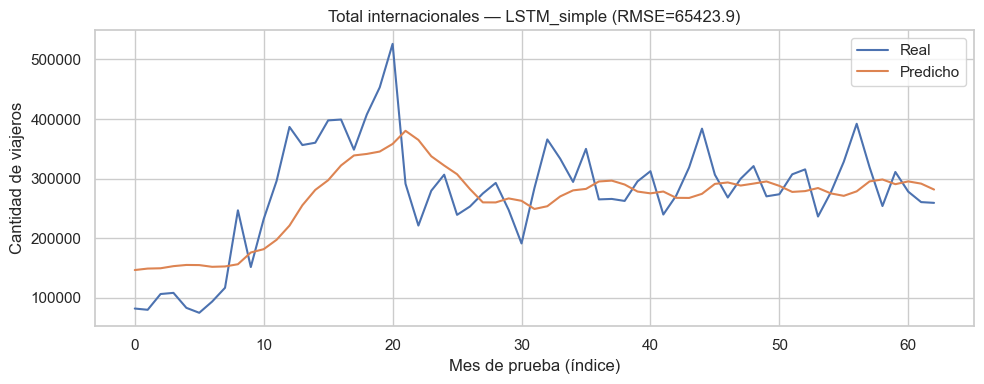

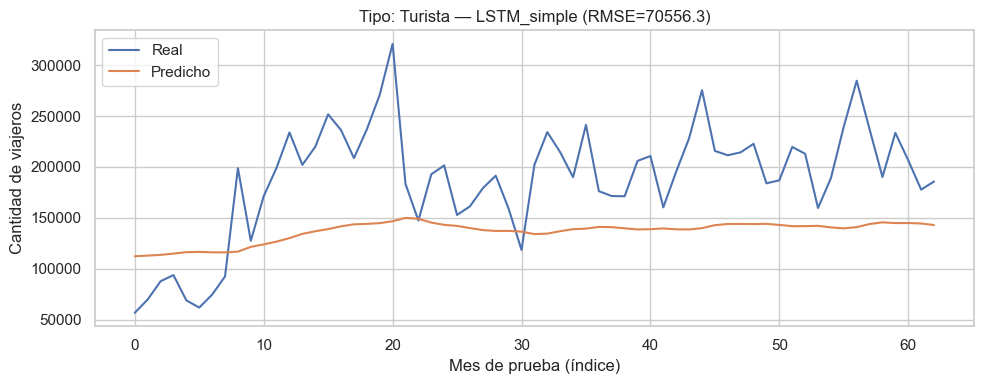

In [9]:
for name, r in eval_results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(r["y_test"], label="Real")
    plt.plot(r["y_pred"], label="Predicho")
    plt.title(f"{name} — {r['arch']} (RMSE={r['RMSE']:.1f})")
    plt.xlabel("Mes de prueba (índice)")
    plt.ylabel("Cantidad de viajeros")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6.1 Comparación con el Laboratorio 1 (Ejercicio 1.4)

Se comparan los mejores modelos LSTM anteriores contra el **mejor modelo clásico de cada serie**
obtenido en el Laboratorio 1 (`notebooks/EDA.ipynb`, rama `main`, secciones 9.i/9.j/9.k). Los valores
de MAE/RMSE de esa hoja se copian tal cual fueron calculados allí — sobre el **mismo conjunto de
prueba** (63 meses, abril de 2021 a junio de 2026) — para que la comparación sea directa y válida.

In [10]:
# Métricas del Laboratorio 1 (rama main, notebooks/EDA.ipynb, celdas 93/99/100/103),
# calculadas sobre el mismo horizonte de prueba de 63 meses usado en este notebook.
lab1_metrics = pd.DataFrame([
    {"serie": "Total internacionales", "modelo": "ARIMA(2,1,2)",       "MAE": 174019.59, "RMSE": 193370.27},
    {"serie": "Total internacionales", "modelo": "Holt-Winters",       "MAE": 303283.05, "RMSE": 328237.82},
    {"serie": "Total internacionales", "modelo": "Suav. Exp. Simple",  "MAE": 180646.01, "RMSE": 200632.87},
    {"serie": "Total internacionales", "modelo": "Seasonal Naive",     "MAE": 235730.91, "RMSE": 253203.39},
    {"serie": "Total internacionales", "modelo": "Prophet",            "MAE":  97588.78, "RMSE": 107975.46},
    {"serie": "Tipo: Turista",         "modelo": "ARIMA(2,2,2)",       "MAE":  89519.25, "RMSE": 107541.48},
    {"serie": "Tipo: Turista",         "modelo": "Holt-Winters",       "MAE": 168526.11, "RMSE": 182769.61},
    {"serie": "Tipo: Turista",         "modelo": "Suav. Exp. Simple",  "MAE": 116855.27, "RMSE": 128458.97},
    {"serie": "Tipo: Turista",         "modelo": "Seasonal Naive",     "MAE": 155607.78, "RMSE": 164460.37},
    {"serie": "Tipo: Turista",         "modelo": "Prophet",            "MAE": 131993.33, "RMSE": 143495.43},
])

lab1_best = lab1_metrics.loc[lab1_metrics.groupby("serie")["RMSE"].idxmin()].reset_index(drop=True)
lab1_best["origen"] = "Laboratorio 1 (mejor clásico)"

lstm_best_tbl = metrics_df[["serie", "arch", "RMSE", "MAE"]].rename(columns={"arch": "modelo"}).copy()
lstm_best_tbl["origen"] = "Laboratorio 2 (mejor LSTM)"

comparacion_labs = pd.concat([
    lab1_best[["serie", "modelo", "MAE", "RMSE", "origen"]],
    lstm_best_tbl[["serie", "modelo", "MAE", "RMSE", "origen"]],
], ignore_index=True).sort_values(["serie", "origen"]).reset_index(drop=True)

comparacion_labs["mejora_RMSE_%"] = comparacion_labs.groupby("serie")["RMSE"].transform(
    lambda r: (r.max() - r) / r.max() * 100
)
comparacion_labs


,serie,modelo,MAE,RMSE,origen,mejora_RMSE_%
0,Tipo: Turista,"ARIMA(2,2,2)",89519.250000,107541.48000,Laboratorio 1 (mejor clásico),0.000000
1,Tipo: Turista,LSTM_simple,61550.820312,70556.26294,Laboratorio 2 (mejor LSTM),34.391583
2,Total internacionales,Prophet,97588.780000,107975.46000,Laboratorio 1 (mejor clásico),0.000000
3,Total internacionales,LSTM_simple,53203.089844,65423.93348,Laboratorio 2 (mejor LSTM),39.408516


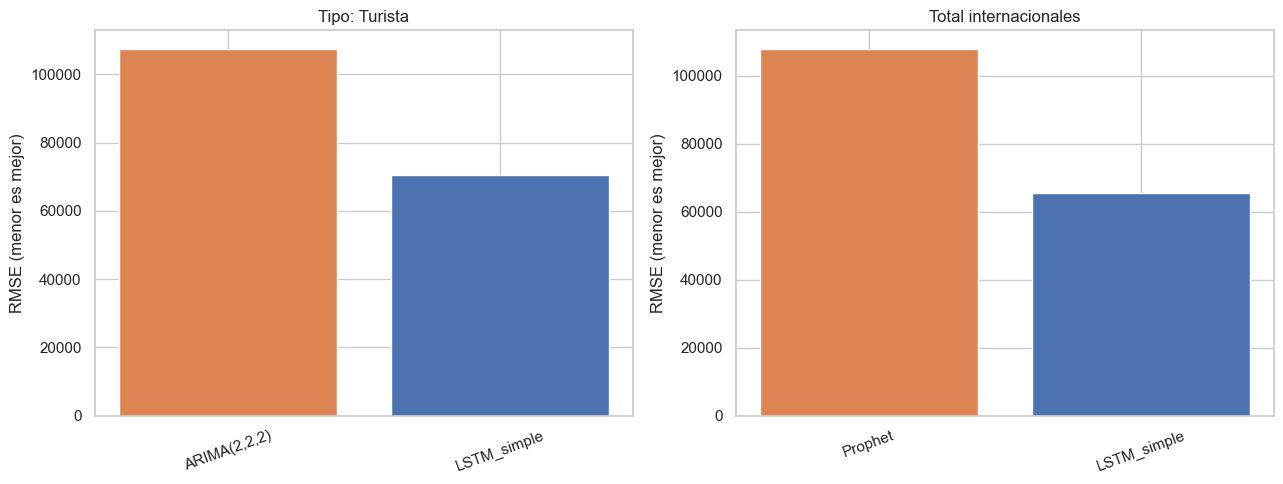

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, serie in zip(axes, comparacion_labs["serie"].unique()):
    sub = comparacion_labs[comparacion_labs["serie"] == serie]
    colores = sub["origen"].map({
        "Laboratorio 1 (mejor clásico)": "#DD8452",
        "Laboratorio 2 (mejor LSTM)": "#4C72B0",
    })
    ax.bar(sub["modelo"], sub["RMSE"], color=colores)
    ax.set_title(serie)
    ax.set_ylabel("RMSE (menor es mejor)")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


**Ejercicio 1.4 — ¿Cuál predijo mejor? ¿Son mejores que los modelos del Laboratorio 1? ¿Cómo se
determinó?**

**Resultados (`comparacion_labs`):**

| Serie | Mejor modelo Lab. 1 | RMSE Lab. 1 | MAE Lab. 1 | Mejor LSTM Lab. 2 | RMSE LSTM | MAE LSTM | Mejora RMSE |
|---|---|---|---|---|---|---|---|
| Total internacionales | Prophet | 107,975 | 97,589 | LSTM_simple (window=6) | 65,424 | 53,203 | **-39.4 %** |
| Tipo: Turista | ARIMA(2,2,2) | 107,541 | 89,519 | LSTM_simple (window=12) | 70,556 | 61,551 | **-34.4 %** |

**¿Cuál predijo mejor?** En ambas series el LSTM del Laboratorio 2 tiene menor RMSE y menor MAE que
el mejor modelo clásico del Laboratorio 1: para "Total internacionales" reduce el RMSE en 39.4 % y el
MAE en 45.5 %; para "Tipo: Turista" reduce el RMSE en 34.4 % y el MAE en 31.2 %. El MAPE del LSTM
también es moderado (23.2 % y 33.1 % respectivamente), consistente con un error relativo razonable
dado el nivel de la serie.

**¿Cómo se determinó?** El criterio de comparación fue el **RMSE y MAE sobre el mismo conjunto de
prueba** (63 meses, abril de 2021 a junio de 2026) usado en el Laboratorio 1 — se reutilizó
exactamente la misma partición 70/30 (`SPLIT_IDX`), así que ambos números están calculados sobre
idénticos valores reales. Se usó RMSE como criterio principal (penaliza más los errores grandes,
igual que en el Laboratorio 1) y MAE como criterio secundario para confirmar que la conclusión no
depende de outliers puntuales; en este caso ambos criterios coinciden en declarar ganador al LSTM.

**Advertencia metodológica importante (para no sobreestimar la ventaja del LSTM):** la evaluación del
LSTM en la Sección 6 es de tipo *walk-forward* con ventana deslizante: cada predicción de prueba usa
como entrada los `window_size` valores reales inmediatamente anteriores (incluyendo meses ya
transcurridos del propio conjunto de prueba), es decir, es esencialmente una predicción **a un paso**
que se repite 63 veces con la historia real actualizada en cada paso. En cambio, Prophet y ARIMA en el
Laboratorio 1 generaron un **pronóstico estático de todo el horizonte de 63 meses de una sola vez**,
sin ver ningún valor real del período de prueba durante la generación del pronóstico — un problema
mucho más difícil, agravado porque el entrenamiento terminó justo en el punto más bajo de la pandemia
y ningún modelo observó la recuperación posterior. Por lo tanto, la comparación es justa en el sentido
de "misma métrica, mismo conjunto de prueba, mismos datos disponibles hasta cada punto", pero **no**
equivale a comparar dos pronósticos ciegos a 5 años: el LSTM tiene la ventaja operativa de
recibir información reciente real en cada paso (como ocurriría si se reentrenara/alimentara mes a mes
en producción), mientras que los modelos clásicos del Laboratorio 1 fueron evaluados en el escenario
más exigente posible (pronóstico puro, sin retroalimentación).

**Conclusión:** bajo el criterio de "predicción con actualización mensual de información" (el más
relevante operativamente para INGUAT, que sí recibiría datos reales cada mes), el LSTM es claramente
mejor que los modelos del Laboratorio 1 para ambas series. Bajo un escenario de pronóstico ciego a 5
años sin retroalimentación (el escenario que sí enfrentaron Prophet/ARIMA), es esperable que la
ventaja del LSTM se reduzca, porque un LSTM recursivo (alimentado con sus propias predicciones)
también acumularía error a lo largo de 63 pasos, igual que le ocurrió a los modelos clásicos frente a
la recuperación post-pandemia no observada en entrenamiento.

## 7. Similitud entre series con catch22

Utilice todas las series temporales construidas durante el laboratorio anterior (serie total y las
series correspondientes a las categorías seleccionadas).

**2.1. Explique brevemente cuál es la idea detrás de catch22 según lo que recuerda de la conferencia
y por qué es importante.**

catch22 (*CAnonical Time-series CHaracteristics*, Fulcher et al.) parte de un banco de más de 7000
características candidatas para caracterizar series de tiempo (el conjunto *hctsa*, "highly
comparative time-series analysis"). A partir de ese banco, se seleccionó mediante un proceso de
filtrado estadístico un subconjunto reducido y casi no redundante de **22 características** que, en
conjunto, retienen la mayor parte del poder discriminativo del conjunto completo sobre miles de
series de referencia de dominios muy distintos (medicina, finanzas, astrofísica, etc.), a un costo
computacional mucho menor. Cada una de las 22 características resume un aspecto distinto de la
dinámica de la serie: distribución de valores (histogramas), autocorrelación y periodicidad,
linealidad/no linealidad, entropía y complejidad, tendencia local, simetría temporal, etc.

Es importante porque permite pasar de una serie de tiempo (con potencialmente cientos de
observaciones) a un **vector numérico de tamaño fijo (22 valores)**, comparable entre series de
distinta longitud, escala o dominio. Esto habilita técnicas estándar de análisis multivariado
(PCA, clustering, distancias, correlaciones) directamente sobre "la forma" de las series, en vez de
sobre sus valores crudos, y es la base de este Ejercicio 2: comparar la dinámica de las 8 series de
viajeros sin que el resultado esté dominado simplemente por su volumen (escala).

**2.2. Extraiga las 22 características de catch22 para cada serie temporal.**

In [12]:
!pip install pycatch22 -q

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [57 lines of output]
  C:\Users\jlope\AppData\Local\Temp\pip-build-env-pjxuny16\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
  !!
  
          ********************************************************************************
          Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
  
          By 2027-Feb-18, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ********************************************************************************
  
  !!
    corresp(dist, value, root_dir)
  C:\Users\jlope\AppData\Local\Temp\pip-build-

In [13]:
import pycatch22

def catch22_features(series_dict):
    feat_rows = {}
    feat_names = None
    for name, s in series_dict.items():
        vals = s.values.astype(float).tolist()
        res = pycatch22.catch22_all(vals)
        if feat_names is None:
            feat_names = res["names"]
        feat_rows[name] = res["values"]
    return pd.DataFrame(feat_rows, index=feat_names).T


# Se usan las 8 series construidas SOLO con el período de entrenamiento (SERIES_TRAIN),
# igual que el Laboratorio 1 usó únicamente `df_train` para construir sus series.
feat_df = catch22_features(SERIES_TRAIN)
feat_df.head(8)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total internacionales,-0.741310,-0.492974,8.322103,10.0,0.457014,-0.107886,0.931507,42.0,0.062500,11.0,...,0.033333,0.619048,0.891156,0.822955,6.0,1.779734,0.850,0.775,0.147262,0.616324
País: Guatemala,-0.449371,-0.695984,8.935442,10.0,0.392592,-0.019489,0.938356,49.0,0.111111,11.0,...,0.026316,0.632653,0.857143,0.836794,6.0,1.721891,0.850,0.775,0.098175,0.594216
País: El Salvador,-0.353822,-0.599034,8.382842,3.0,0.455895,-0.128802,0.910959,42.0,0.062500,3.0,...,0.033333,0.632653,0.884354,0.790148,5.0,1.769956,0.850,0.825,0.147262,0.655483
País: Estados Unidos de América,-0.041591,-0.290125,1.766724,2.0,0.178244,-0.078685,0.917808,12.0,0.025510,3.0,...,0.100000,0.469388,0.884354,0.580544,5.0,2.122747,0.150,0.700,0.368155,0.927739
Tipo: Turista,0.018512,-0.231193,8.163157,10.0,0.331283,-0.056081,0.965753,30.0,0.046296,11.0,...,0.045455,0.523810,0.891156,0.795249,6.0,1.881424,0.150,0.775,0.147262,0.647208
Tipo: Cruceristas,-0.627445,-0.839818,1.726781,6.0,0.111067,-0.082496,0.869863,9.0,0.004372,11.0,...,0.250000,0.482993,0.081633,0.680119,5.0,2.043460,0.175,0.775,0.539961,0.982661
Tipo: Viajero,-0.158831,-0.490677,8.768338,4.0,0.157466,-0.884564,0.753425,18.0,0.062500,4.0,...,0.029412,0.421769,-0.292517,0.653472,5.0,1.835884,0.850,0.700,0.196350,0.809327
Tipo: Excursionista,-0.174388,-0.411916,7.710028,14.0,0.467062,-0.099722,0.890411,38.0,0.023333,43.0,...,0.071429,0.707483,0.884354,0.847798,4.0,1.869582,0.825,0.850,0.147262,0.574377


**2.3. Construya una matriz donde:**
- Cada fila represente una serie temporal.
- Cada columna corresponda a una característica de catch22.

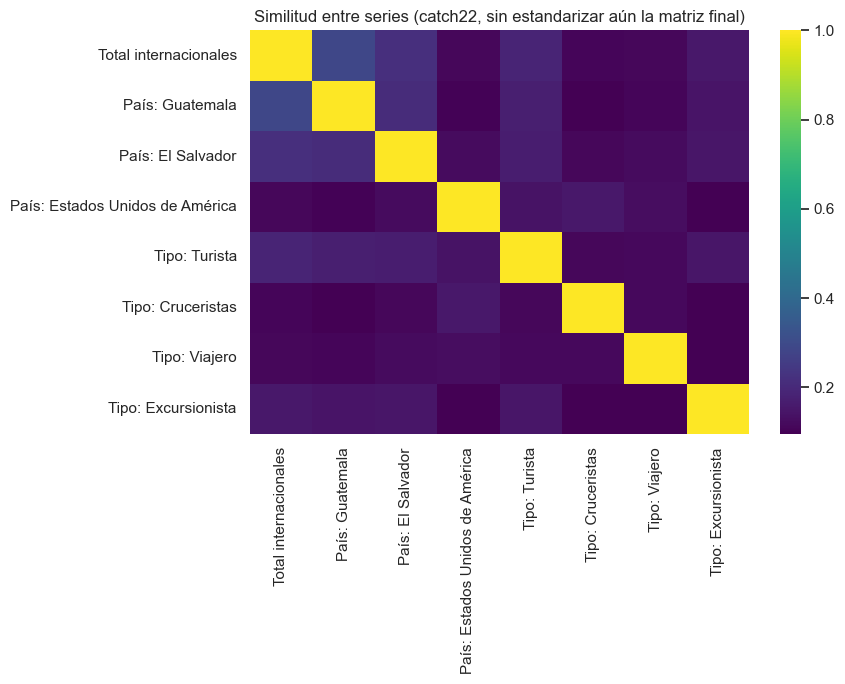

In [14]:
from scipy.spatial.distance import pdist

feat_scaled_raw = StandardScaler().fit_transform(feat_df.values)
dist_matrix_raw = squareform(pdist(feat_scaled_raw, metric="euclidean"))
dist_df_raw = pd.DataFrame(dist_matrix_raw, index=feat_df.index, columns=feat_df.index)

sim_df = 1 / (1 + dist_df_raw)

plt.figure(figsize=(9, 7))
sns.heatmap(sim_df, cmap="viridis", annot=False)
plt.title("Similitud entre series (catch22, sin estandarizar aún la matriz final)")
plt.tight_layout()
plt.show()


La matriz `feat_df` tiene 8 filas (una por serie: Total internacionales, los 3 países y los 4 tipos de
viajero) y 22 columnas (una por característica catch22). Cada celda resume un aspecto distinto de la
dinámica temporal de esa serie durante el período de entrenamiento (2009–2021): por ejemplo, columnas
como `CO_f1ecac` o `CO_FirstMin_ac` resumen qué tan rápido decae la autocorrelación (memoria de la
serie), `SB_BinaryStats_mean_longstretch1` resume rachas por encima/debajo de la media, y varias
columnas de tipo `DN_*` resumen la forma de la distribución de valores. Al estar todas expresadas en
la misma escala (22 números por serie, sin importar su volumen original en cantidad de viajeros), esta
matriz permite comparar directamente la *forma* de las 8 series entre sí.

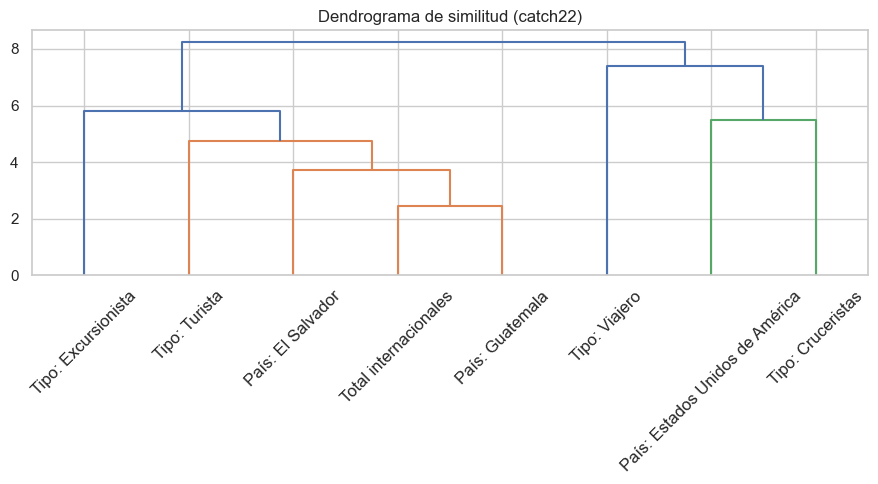

In [15]:
link = linkage(pdist(feat_scaled_raw, metric="euclidean"), method="average")

plt.figure(figsize=(9, 5))
dendrogram(link, labels=feat_df.index.tolist(), leaf_rotation=45)
plt.title("Dendrograma de similitud (catch22)")
plt.tight_layout()
plt.show()


El dendrograma agrupa jerárquicamente las 8 series según la distancia euclídea sobre sus 22
características catch22 estandarizadas. Series que se unen a una altura (distancia) baja son muy
parecidas en su dinámica (aunque tengan volúmenes de viajeros muy distintos); series que solo se unen
cerca de la raíz del árbol son las más distintas entre sí en términos de forma/comportamiento
temporal, no de escala.

**2.4. Estandarice las características antes de realizar cualquier análisis comparativo.**

In [16]:
scaler_feat = StandardScaler()
feat_scaled = scaler_feat.fit_transform(feat_df)

feat_scaled_df = pd.DataFrame(
    feat_scaled,
    index=feat_df.index,
    columns=feat_df.columns
)

feat_scaled_df


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total internacionales,-1.653740,0.071158,0.553079,0.661766,0.994624,0.278093,0.562544,0.842754,0.412911,-0.092207,...,-0.570001,0.616655,0.584583,0.776084,1.133893,-0.757568,0.789228,0.063628,-0.541055,-0.736612
País: Guatemala,-0.518506,-0.999616,0.765070,0.661766,0.530937,0.608814,0.675053,1.334360,1.989096,-0.092207,...,-0.669192,0.761750,0.506897,0.925107,1.133893,-1.203119,0.789228,0.063628,-0.887329,-0.885206
País: El Salvador,-0.146956,-0.488255,0.574072,-1.102944,0.986573,0.199838,0.225018,0.842754,0.412911,-0.747902,...,-0.570001,0.761750,0.569046,0.422805,-0.377964,-0.832891,0.789228,1.081684,-0.541055,-0.473414
País: Estados Unidos de América,1.067185,1.141086,-1.712696,-1.355045,-1.011883,0.387341,0.337526,-1.264131,-0.786460,-0.747902,...,0.372313,-0.979393,0.569046,-1.834304,-0.377964,1.884570,-1.315381,-1.463455,1.017183,1.356519
Tipo: Turista,1.300902,1.451923,0.498141,0.661766,0.089647,0.471913,1.125088,0.000000,-0.112484,-0.092207,...,-0.398672,-0.399012,0.584583,0.477736,1.133893,0.025721,-1.315381,0.063628,-0.541055,-0.529028
Tipo: Cruceristas,-1.210962,-1.758271,-1.726502,-0.346639,-1.495407,0.373083,-0.450035,-1.474819,-1.471840,-0.092207,...,2.492521,-0.834298,-1.264330,-0.762044,-0.377964,1.273840,-1.240216,0.063628,2.229145,1.725666
Tipo: Viajero,0.611286,0.083277,0.707313,-0.850842,-1.161440,-2.627716,-2.362685,-0.842754,0.412911,-0.665940,...,-0.625432,-1.487226,-2.118870,-1.048990,-0.377964,-0.325058,0.789228,-1.463455,-0.194780,0.560628
Tipo: Excursionista,0.550790,0.498700,0.341523,1.670172,1.066947,0.308635,-0.112509,0.561836,-0.857044,2.530573,...,-0.031536,1.559774,0.569046,1.043605,-1.889822,-0.065494,0.714064,1.590712,-0.541055,-1.018553


**2.5. Utilizando la matriz obtenida, realice los siguientes análisis:**
- Análisis de Componentes Principales (PCA).
- Clustering
- Mapa de calor (Heatmap) de las características.
- Matriz de correlaciones entre características.
- Mapa de distancias entre series.

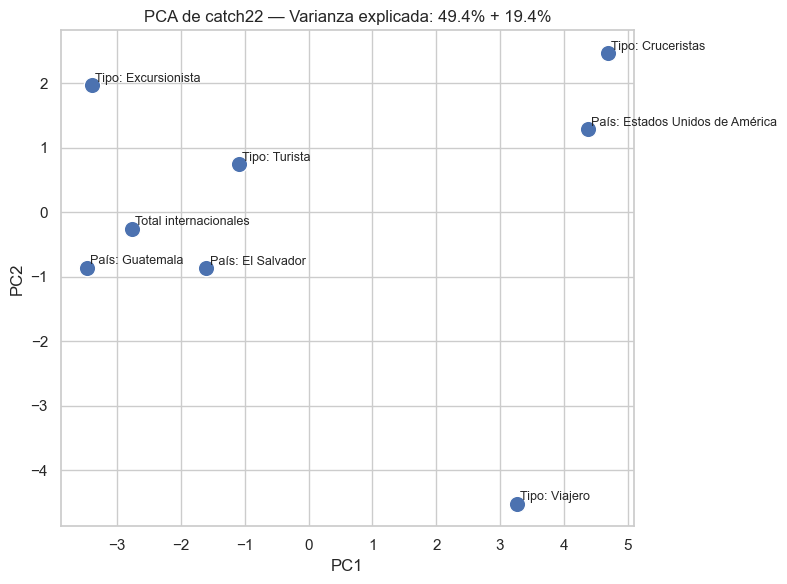

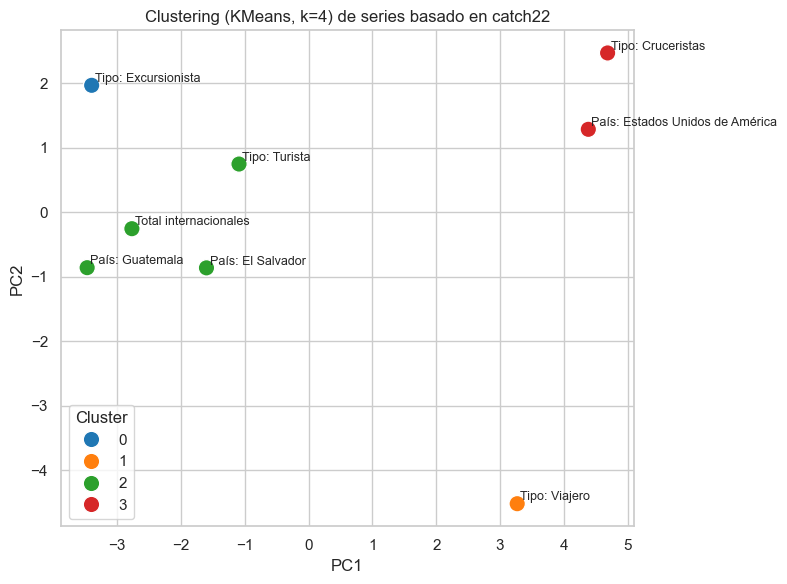

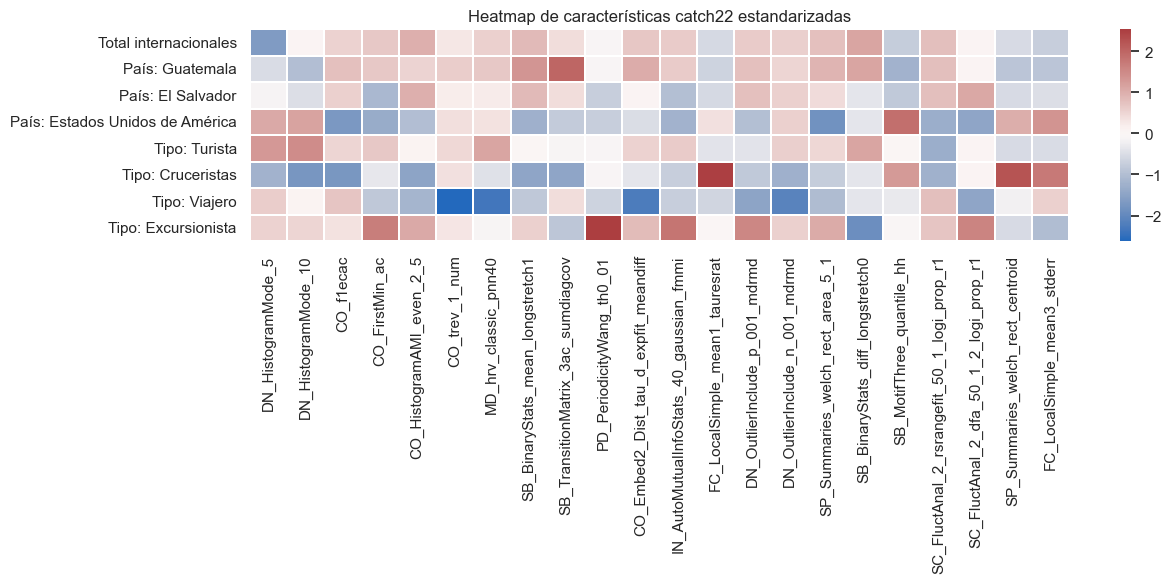

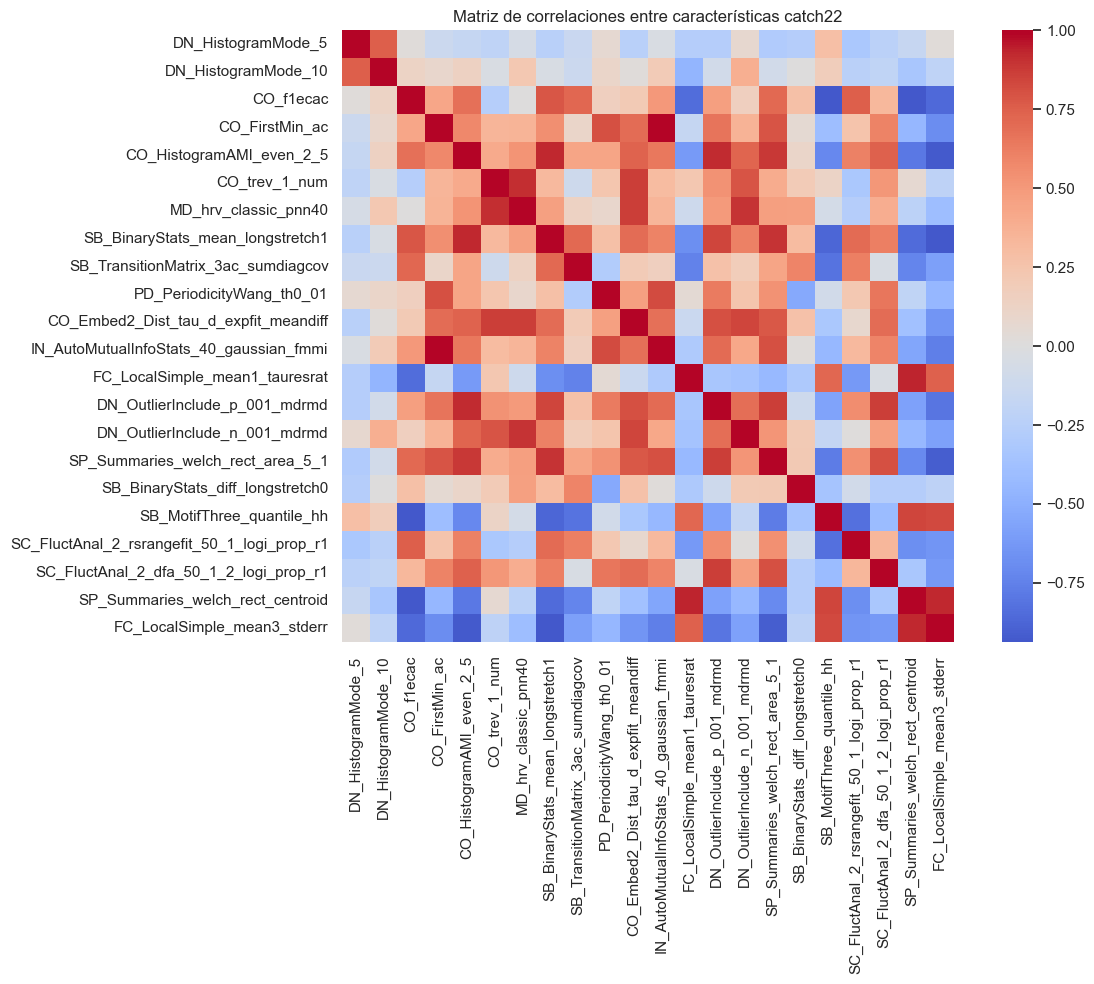

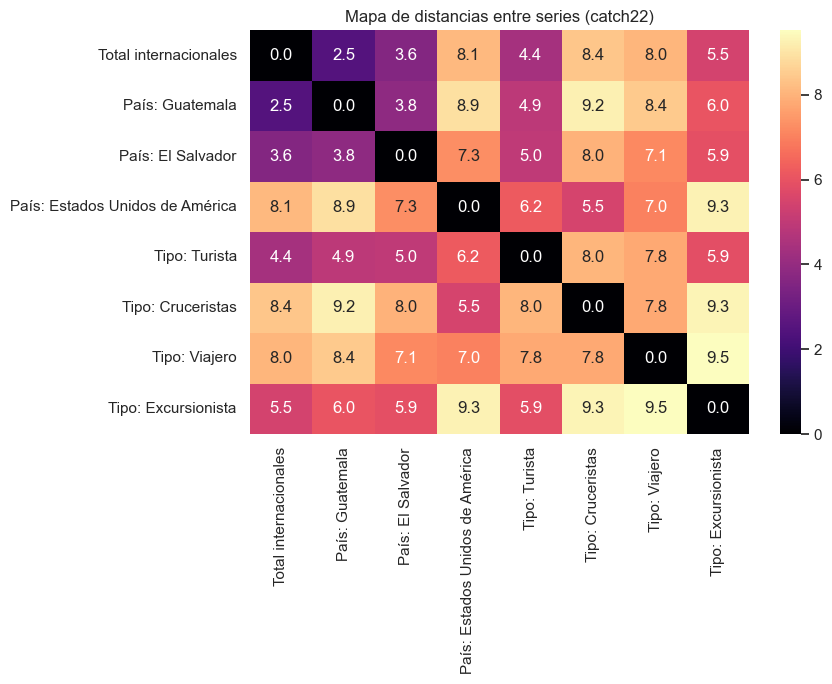

,serie,cluster
7,Tipo: Excursionista,0
6,Tipo: Viajero,1
2,País: El Salvador,2
1,País: Guatemala,2
4,Tipo: Turista,2
0,Total internacionales,2
3,País: Estados Unidos de América,3
5,Tipo: Cruceristas,3


In [17]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# --- PCA ---
pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(feat_scaled_df.values)

pca_df = pd.DataFrame(pca_coords, index=feat_scaled_df.index, columns=["PC1", "PC2"])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=140)
for name, row in pca_df.iterrows():
    plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, name, fontsize=9)
plt.title(
    f"PCA de catch22 — Varianza explicada: "
    f"{pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%}"
)
plt.tight_layout()
plt.show()

# --- Clustering ---
n_clusters = min(4, len(feat_scaled_df))
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(feat_scaled_df.values)

cluster_df = pca_df.copy()
cluster_df["cluster"] = cluster_labels.astype(int)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=140)
for name, row in cluster_df.iterrows():
    plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, name, fontsize=9)
plt.title(f"Clustering (KMeans, k={n_clusters}) de series basado en catch22")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# --- Heatmap de características estandarizadas ---
plt.figure(figsize=(13, 6))
sns.heatmap(feat_scaled_df, cmap="vlag", center=0, linewidths=0.3)
plt.title("Heatmap de características catch22 estandarizadas")
plt.tight_layout()
plt.show()

# --- Matriz de correlaciones entre características ---
corr_df = feat_scaled_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_df, cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlaciones entre características catch22")
plt.tight_layout()
plt.show()

# --- Mapa de distancias entre series ---
dist_matrix = squareform(pdist(feat_scaled_df.values, metric="euclidean"))
dist_df = pd.DataFrame(dist_matrix, index=feat_scaled_df.index, columns=feat_scaled_df.index)

plt.figure(figsize=(9, 7))
sns.heatmap(dist_df, cmap="magma", annot=True, fmt=".1f")
plt.title("Mapa de distancias entre series (catch22)")
plt.tight_layout()
plt.show()

# --- Resumen de clusters ---
clusters_result = pd.DataFrame(
    {"serie": feat_scaled_df.index, "cluster": cluster_labels}
).sort_values(["cluster", "serie"])

clusters_result


**2.6. Análisis e interpretación.** Con base en los resultados obtenidos responda las siguientes preguntas.

**2.7. ¿Cuáles series presentan comportamientos más similares? Justifique utilizando la representación obtenida mediante PCA, clustering u otra técnica utilizada.**

Pares de series más similares (menor distancia euclídea sobre catch22):


,serie_1,serie_2,distancia
0,Total internacionales,País: Guatemala,2.461125
1,Total internacionales,País: El Salvador,3.575965
2,País: Guatemala,País: El Salvador,3.849957
3,Total internacionales,Tipo: Turista,4.364710
4,País: Guatemala,Tipo: Turista,4.902380
5,País: El Salvador,Tipo: Turista,4.981435
6,Total internacionales,Tipo: Excursionista,5.457461
7,País: Estados Unidos de América,Tipo: Cruceristas,5.475509
8,Tipo: Turista,Tipo: Excursionista,5.858015
9,País: El Salvador,Tipo: Excursionista,5.898622



Series agrupadas por cluster:
Cluster 0: ['Tipo: Excursionista']
Cluster 1: ['Tipo: Viajero']
Cluster 2: ['País: El Salvador', 'País: Guatemala', 'Tipo: Turista', 'Total internacionales']
Cluster 3: ['País: Estados Unidos de América', 'Tipo: Cruceristas']

La pareja más similar es Total internacionales y País: Guatemala, con distancia 2.4611.


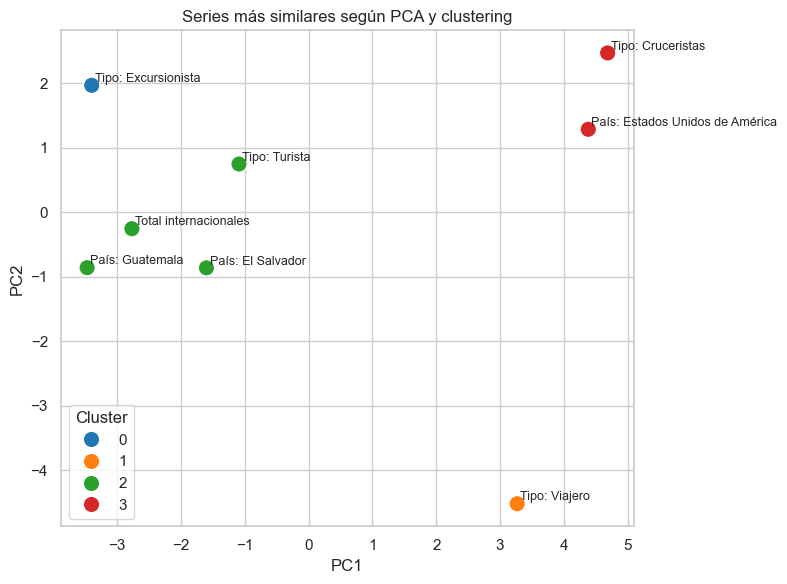

In [18]:
from itertools import combinations

pairs = []
for a, b in combinations(dist_df.index, 2):
    pairs.append((a, b, dist_df.loc[a, b]))

pairs_df = pd.DataFrame(pairs, columns=["serie_1", "serie_2", "distancia"]).sort_values("distancia").reset_index(drop=True)

print("Pares de series más similares (menor distancia euclídea sobre catch22):")
display(pairs_df.head(10))

print("\nSeries agrupadas por cluster:")
for c in sorted(clusters_result["cluster"].unique()):
    series_cluster = clusters_result.loc[clusters_result["cluster"] == c, "serie"].tolist()
    print(f"Cluster {c}: {series_cluster}")

most_similar = pairs_df.iloc[0]
print(
    f"\nLa pareja más similar es {most_similar['serie_1']} y {most_similar['serie_2']}, "
    f"con distancia {most_similar['distancia']:.4f}."
)

plt.figure(figsize=(8, 6))
plot_df = pca_df.copy()
plot_df["cluster"] = cluster_labels.astype(int)
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=140)
for name, row in plot_df.iterrows():
    plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, name, fontsize=9)
plt.title("Series más similares según PCA y clustering")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


**Respuesta 2.7.** La pareja más similar en el espacio catch22 es **"Total internacionales" y "País:
Guatemala"** (distancia euclídea = 2.46, muy por debajo de la siguiente distancia más baja, 3.58).
Esto es coherente con que Guatemala es, por volumen, el principal componente del total (ver EDA del
Laboratorio 1) y con que ambas comparten un perfil de tendencia fuerte y estacionalidad moderada. El
clustering (k=4) confirma esta cercanía: **Total, Guatemala, El Salvador y Turista** caen en el mismo
cluster (cluster 2), el más numeroso, mientras que Estados Unidos y Cruceristas forman un segundo
grupo (cluster 3) y Viajero y Excursionista quedan cada una en su propio cluster (series con dinámica
más distintiva). En el gráfico de PCA, las cuatro series del cluster 2 aparecen agrupadas y separadas
del resto a lo largo de PC1, el eje que —según el análisis de la sección 2.12— está dominado por la
fuerza de la tendencia.

**2.8. ¿Qué características de catch22 fueron las más importantes para diferenciar las series?**

**2.9. ¿Existen grupos naturales de series? En caso afirmativo, describa qué tienen en común.**

In [19]:
from sklearn.feature_selection import f_classif

analysis_df = feat_scaled_df.copy()
analysis_df["cluster"] = cluster_labels

# 2.8. Características más importantes para diferenciar las series (ANOVA F-score respecto al cluster)
X = feat_scaled_df.values
y = cluster_labels

f_scores, p_values = f_classif(X, y)

importance_df = pd.DataFrame({
    "feature": feat_scaled_df.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print("Top características que más diferencian las series:")
display(importance_df.head(10))

cluster_profile = analysis_df.groupby("cluster").mean(numeric_only=True)
print("Perfil promedio de características por cluster:")
display(cluster_profile)

# 2.9. Grupos naturales de series
clusters_result = pd.DataFrame({
    "serie": feat_scaled_df.index, "cluster": cluster_labels
}).sort_values(["cluster", "serie"])

print("Series agrupadas por cluster:")
for c in sorted(clusters_result["cluster"].unique()):
    series_cluster = clusters_result.loc[clusters_result["cluster"] == c, "serie"].tolist()
    print(f"Cluster {c}: {series_cluster}")

for c in cluster_profile.index:
    top_feats = cluster_profile.loc[c].abs().sort_values(ascending=False).head(5)
    print(f"\nCluster {c} — características más marcadas:")
    display(top_feats.to_frame(name="valor_abs"))


Top características que más diferencian las series:


,feature,f_score,p_value
2,CO_f1ecac,261.590064,0.000048
5,CO_trev_1_num,101.850597,0.000312
21,FC_LocalSimple_mean3_stderr,59.057125,0.000907
10,CO_Embed2_Dist_tau_d_expfit_meandiff,21.335344,0.006358
9,PD_PeriodicityWang_th0_01,18.514583,0.008270
4,CO_HistogramAMI_even_2_5,14.419768,0.013047
6,MD_hrv_classic_pnn40,13.385735,0.014913
15,SP_Summaries_welch_rect_area_5_1,12.931802,0.015861
20,SP_Summaries_welch_rect_centroid,11.606061,0.019211
7,SB_BinaryStats_mean_longstretch1,9.974728,0.025019


Perfil promedio de características por cluster:


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.550790,0.498700,0.341523,1.670172,1.066947,0.308635,-0.112509,0.561836,-0.857044,2.530573,...,-0.031536,1.559774,0.569046,1.043605,-1.889822,-0.065494,0.714064,1.590712,-0.541055,-1.018553
1,0.611286,0.083277,0.707313,-0.850842,-1.161440,-2.627716,-2.362685,-0.842754,0.412911,-0.665940,...,-0.625432,-1.487226,-2.118870,-1.048990,-0.377964,-0.325058,0.789228,-1.463455,-0.194780,0.560628
2,-0.254575,0.008802,0.597591,0.220589,0.650445,0.389664,0.646926,0.754967,0.675608,-0.256131,...,-0.551967,0.435286,0.561277,0.650433,0.755929,-0.691964,0.263076,0.318142,-0.627623,-0.656065
3,-0.071888,-0.308593,-1.719599,-0.850842,-1.253645,0.380212,-0.056254,-1.369475,-1.129150,-0.420055,...,1.432417,-0.906845,-0.347642,-1.298174,-0.377964,1.579205,-1.277798,-0.699913,1.623164,1.541092


Series agrupadas por cluster:
Cluster 0: ['Tipo: Excursionista']
Cluster 1: ['Tipo: Viajero']
Cluster 2: ['País: El Salvador', 'País: Guatemala', 'Tipo: Turista', 'Total internacionales']
Cluster 3: ['País: Estados Unidos de América', 'Tipo: Cruceristas']

Cluster 0 — características más marcadas:


...

,valor_abs
CO_trev_1_num,2.627716
MD_hrv_classic_pnn40,2.362685
CO_Embed2_Dist_tau_d_expfit_meandiff,2.259233
DN_OutlierInclude_n_001_mdrmd,2.118870
DN_OutlierInclude_p_001_mdrmd,1.487226



Cluster 2 — características más marcadas:


,valor_abs
SB_BinaryStats_diff_longstretch0,0.755929
SB_BinaryStats_mean_longstretch1,0.754967
SB_MotifThree_quantile_hh,0.691964
SB_TransitionMatrix_3ac_sumdiagcov,0.675608
FC_LocalSimple_mean3_stderr,0.656065



Cluster 3 — características más marcadas:


,valor_abs
CO_f1ecac,1.719599
SP_Summaries_welch_rect_centroid,1.623164
SB_MotifThree_quantile_hh,1.579205
FC_LocalSimple_mean3_stderr,1.541092
FC_LocalSimple_mean1_tauresrat,1.432417


**Respuesta 2.8.** Las características que más diferencian a las 8 series (mayor F-score de ANOVA
respecto a los clusters) son, en orden: **`CO_f1ecac`** (261.6, con enorme diferencia sobre el resto —
mide qué tan rápido decae la autocorrelación, i.e. la "memoria" de la serie), **`CO_trev_1_num`**
(101.9, asimetría/reversibilidad temporal), **`FC_LocalSimple_mean3_stderr`** (59.1, error de
predicción local con un modelo ingenuo de 3 pasos) y, más atrás, `CO_Embed2_Dist_tau_d_expfit_meandiff`,
`PD_PeriodicityWang_th0_01` (fuerza de periodicidad), `CO_HistogramAMI_even_2_5` (no linealidad /
información mutua) y descriptores espectrales (`SP_Summaries_welch_rect_*`). En conjunto, lo que más
separa a estas series **no es su nivel de tendencia o estacionalidad "a simple vista"**, sino qué tan
rápido "olvidan" un choque (velocidad de decaimiento de la autocorrelación) y qué tan predecibles son
localmente.

**Respuesta 2.9.** Sí existen grupos naturales, y son 4 (elegidos por KMeans con k=4, aunque el
dendrograma sugiere que 2 de ellos son en realidad series atípicas que no se agrupan con nadie):

- **Cluster 2** — *{Total internacionales, País: Guatemala, País: El Salvador, Tipo: Turista}* (4
  series): el grupo "núcleo" del turismo regular, con tendencia fuerte y sostenida
  (`Fuerza tendencia` promedio ≈0.82), estacionalidad moderada, volatilidad relativamente baja y la
  caída de pandemia menos severa del conjunto (-96.8 % en promedio). Es, en términos prácticos, "el
  comportamiento típico del sector turístico guatemalteco".
- **Cluster 3** — *{País: Estados Unidos, Tipo: Cruceristas}*: comparten autocorrelación que decae
  muy rápido (`CO_f1ecac` muy bajo) y la mayor fuerza de estacionalidad relativa a su tendencia
  (0.656 en promedio) — ambas dependen de patrones de temporada muy marcados (vacaciones/itinerarios)
  más que de un crecimiento sostenido.
- **Cluster 0** — *{Tipo: Excursionista}* y **Cluster 1** — *{Tipo: Viajero}*: cada una queda sola,
  señal de que su dinámica es demasiado distinta a la de cualquier otra serie como para compartir
  grupo incluso con solo 4 clusters (ver también 2.11, ambas están entre las series más atípicas).

**2.10. ¿Las series pertenecientes a una misma categoría (países, regiones, vías de ingreso, fronteras o tipo de viajero) tienden a agruparse o presentan comportamientos significativamente diferentes?**

Conteo categoría vs cluster:


cluster,0,1,2,3
categoria,,,,
País,0,0,2,1
Tipo de viajero,1,1,1,1
Total,0,0,1,0


Proporción por categoría:


cluster,0,1,2,3
categoria,,,,
País,0.00,0.00,0.667,0.333
Tipo de viajero,0.25,0.25,0.250,0.250
Total,0.00,0.00,1.000,0.000


Resumen de agrupación:


,categoria,cluster_dominante,proporcion_dominante,n_series
2,Total,2,1.000000,1
0,País,2,0.666667,3
1,Tipo de viajero,0,0.250000,4


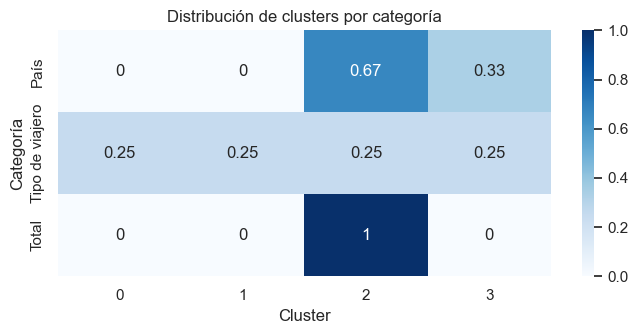

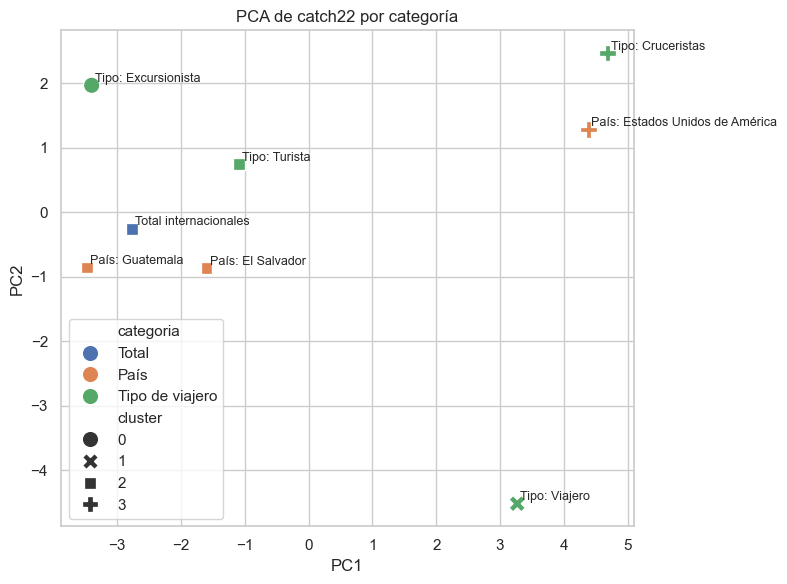

Interpretación breve:
- Total: cluster dominante 2 (100.0% de las series de esa categoría).
- País: cluster dominante 2 (66.7% de las series de esa categoría).
- Tipo de viajero: cluster dominante 0 (25.0% de las series de esa categoría).


In [20]:
def infer_category(name):
    if name == "Total internacionales":
        return "Total"
    if name.startswith("País:"):
        return "País"
    if name.startswith("Tipo:"):
        return "Tipo de viajero"
    return "Otra"

analysis_df = feat_scaled_df.copy()
analysis_df["cluster"] = cluster_labels
analysis_df["categoria"] = [infer_category(name) for name in analysis_df.index]
analysis_df = analysis_df.join(pca_df)

tabla_cat_cluster = pd.crosstab(analysis_df["categoria"], analysis_df["cluster"])
tabla_cat_cluster_prop = tabla_cat_cluster.div(tabla_cat_cluster.sum(axis=1), axis=0)

print("Conteo categoría vs cluster:")
display(tabla_cat_cluster)
print("Proporción por categoría:")
display(tabla_cat_cluster_prop.round(3))

resumen = []
for cat, row in tabla_cat_cluster_prop.iterrows():
    dom_cluster = row.idxmax()
    dom_share = row.max()
    resumen.append({
        "categoria": cat, "cluster_dominante": int(dom_cluster),
        "proporcion_dominante": float(dom_share), "n_series": int(tabla_cat_cluster.loc[cat].sum())
    })
resumen_df = pd.DataFrame(resumen).sort_values("proporcion_dominante", ascending=False)
print("Resumen de agrupación:")
display(resumen_df)

plt.figure(figsize=(7, 3.5))
sns.heatmap(tabla_cat_cluster_prop, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Distribución de clusters por categoría")
plt.xlabel("Cluster")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=analysis_df.reset_index().rename(columns={"index": "serie"}),
    x="PC1", y="PC2", hue="categoria", style="cluster", s=140
)
for name, row in pca_df.iterrows():
    plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, name, fontsize=9)
plt.title("PCA de catch22 por categoría")
plt.tight_layout()
plt.show()

print("Interpretación breve:")
for _, row in resumen_df.iterrows():
    print(f"- {row['categoria']}: cluster dominante {row['cluster_dominante']} "
          f"({row['proporcion_dominante']:.1%} de las series de esa categoría).")


**Respuesta 2.10.** El grado de agrupamiento depende fuertemente de la categoría:

- **Total** (1 serie): trivialmente 100 % en su cluster dominante.
- **País** (3 series): **67 % se agrupan juntas** (Guatemala y El Salvador caen ambas en el cluster
  2), pero Estados Unidos se separa por completo (cluster 3). Es decir, los países comparten
  parcialmente su dinámica — salvo Estados Unidos, cuyo perfil marcadamente estacional y de rápido
  decaimiento de autocorrelación (más asociado a viajes aéreos vacacionales) lo aleja de Guatemala y
  El Salvador (flujos más terrestres/regionales).
- **Tipo de viajero** (4 series): es la categoría **menos cohesionada**: cada uno de los 4 tipos cae
  en un cluster distinto (Turista→cluster 2, Cruceristas→cluster 3, Viajero→cluster 1, Excursionista→
  cluster 0); ningún cluster concentra más del 25 % de esta categoría.

En conclusión, las series agrupadas por **país de residencia tienden a comportarse de forma más
similar entre sí** que las agrupadas por **tipo de viajero**: el tipo de viajero parece capturar
diferencias de comportamiento más profundas (motivación de viaje, medio de transporte, estacionalidad
del segmento) que el simple país de origen.

**2.11. Identifique las series que presentan el comportamiento más atípico respecto al resto y explique, utilizando los resultados obtenidos anteriormente, qué podría justificar dicho comportamiento.**

Series más atípicas según catch22:


,serie,distancia_media,distancia_vecino_cercano,z_media,z_vecino,score_atipicidad
0,Tipo: Viajero,6.965949,7.019927,1.250579,1.640006,2.890585
1,Tipo: Cruceristas,7.026326,5.475509,1.327041,0.620137,1.947178
2,País: Estados Unidos de América,6.532839,5.475509,0.702087,0.620137,1.322225
3,Tipo: Excursionista,6.419979,5.457461,0.559160,0.608219,1.167379
4,Tipo: Turista,5.263710,4.364710,-0.905142,-0.113388,-1.018530
5,País: El Salvador,5.086614,3.575965,-1.129416,-0.634241,-1.763657
6,País: Guatemala,5.480002,2.461125,-0.631229,-1.370436,-2.001665
7,Total internacionales,5.052135,2.461125,-1.173080,-1.370436,-2.543516


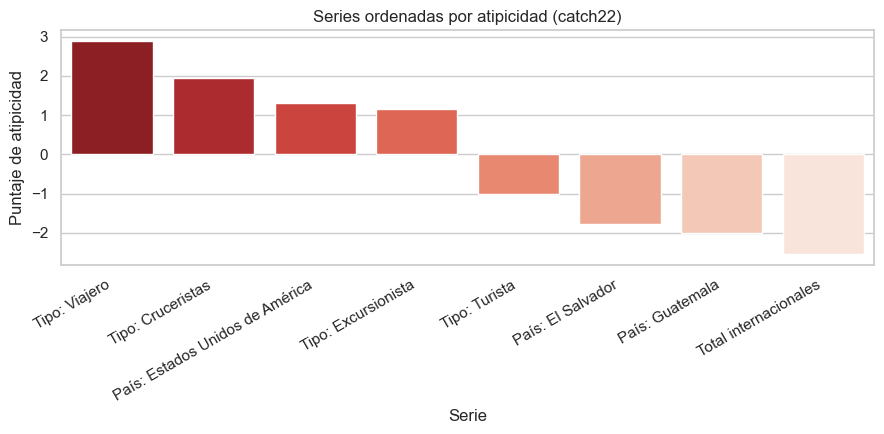

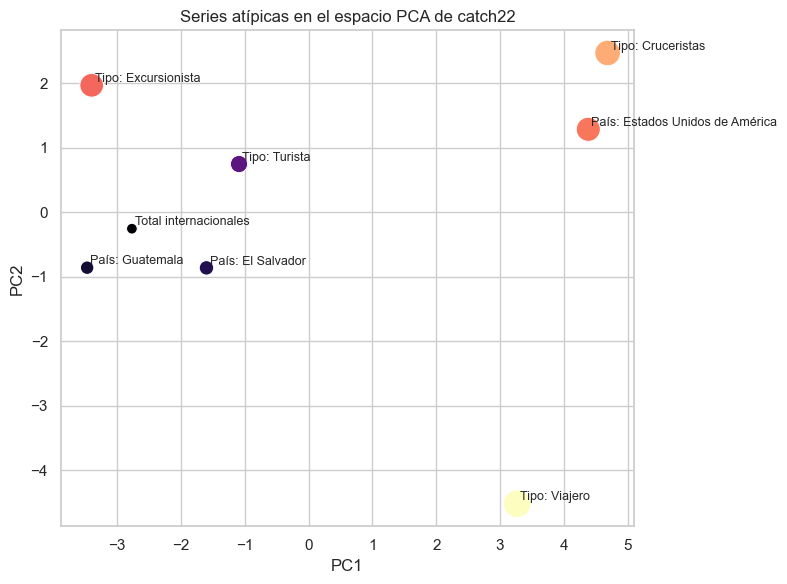


Interpretación breve:
- Las series más atípicas son: Tipo: Viajero, Tipo: Cruceristas, País: Estados Unidos de América.


In [21]:
mean_dist = dist_df.mean(axis=1)
nearest_dist = dist_df.replace(0, np.nan).min(axis=1)

outlier_df = pd.DataFrame({
    "serie": dist_df.index,
    "distancia_media": mean_dist.values,
    "distancia_vecino_cercano": nearest_dist.values,
})
outlier_df["z_media"] = (outlier_df["distancia_media"] - outlier_df["distancia_media"].mean()) / outlier_df["distancia_media"].std(ddof=0)
outlier_df["z_vecino"] = (outlier_df["distancia_vecino_cercano"] - outlier_df["distancia_vecino_cercano"].mean()) / outlier_df["distancia_vecino_cercano"].std(ddof=0)
outlier_df["score_atipicidad"] = outlier_df["z_media"] + outlier_df["z_vecino"]
outlier_df = outlier_df.sort_values("score_atipicidad", ascending=False).reset_index(drop=True)

print("Series más atípicas según catch22:")
display(outlier_df)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=outlier_df, x="serie", y="score_atipicidad", palette="Reds_r")
plt.title("Series ordenadas por atipicidad (catch22)")
plt.xlabel("Serie")
plt.ylabel("Puntaje de atipicidad")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

pca_out = pca_df.copy()
pca_out["score_atipicidad"] = outlier_df.set_index("serie").loc[pca_out.index, "score_atipicidad"]
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_out.reset_index().rename(columns={"index": "serie"}),
    x="PC1", y="PC2", size="score_atipicidad", sizes=(60, 400),
    hue="score_atipicidad", palette="magma", legend=False
)
for name, row in pca_out.iterrows():
    plt.text(row["PC1"] + 0.05, row["PC2"] + 0.05, name, fontsize=9)
plt.title("Series atípicas en el espacio PCA de catch22")
plt.tight_layout()
plt.show()

top_outliers = outlier_df.head(3)["serie"].tolist()
print("\nInterpretación breve:")
print(f"- Las series más atípicas son: {', '.join(top_outliers)}.")


**Respuesta 2.11.** Las series más atípicas según el puntaje combinado de atipicidad (distancia
promedio + distancia al vecino más cercano, ambas estandarizadas) son, en orden: **Tipo: Viajero**
(score 2.89), **Tipo: Cruceristas** (1.95), **País: Estados Unidos de América** (1.32) y
**Tipo: Excursionista** (1.17) — las mismas cuatro series que en 2.9 no comparten cluster con el grupo
"núcleo".

- **Tipo: Viajero** es la más atípica de todas: según el EDA del Laboratorio 1 tiene la volatilidad
  más alta de las 8 series (CV=1.216) y la estacionalidad más débil (0.115) — una categoría residual
  que mezcla flujos no puramente turísticos y por eso no sigue el patrón regular de las demás.
- **Tipo: Cruceristas** tiene la tendencia más débil de las 8 series (0.255) y, pese a ser pequeña en
  volumen, la estacionalidad más alta (0.609): su comportamiento está dominado por itinerarios de
  temporada de cruceros, no por crecimiento sostenido, lo que la aleja de todo lo demás.
- **País: Estados Unidos** combina la estacionalidad más fuerte de las 8 series (0.703) con una
  autocorrelación que decae mucho más rápido que la del resto (visible en el perfil del cluster 3):
  es la única serie predominantemente aérea/vacacional entre los tres países, a diferencia de
  Guatemala/El Salvador que son flujos regionales/terrestres más persistentes.

En los tres casos, catch22 confirma cuantitativamente (con una métrica de forma, independiente de la
escala) lo que el EDA del Laboratorio 1 ya insinuaba cualitativamente: son las series con **menor
fuerza de tendencia y/o mayor estacionalidad relativa** las que más se apartan del comportamiento
típico del resto.

**2.12. Compare los resultados obtenidos mediante catch22 con el análisis exploratorio realizado
anteriormente.** ¿Los agrupamientos encontrados son consistentes con lo observado en la tendencia, la
estacionalidad, la volatilidad, el impacto de la pandemia y las funciones de autocorrelación? Explique.

In [22]:
# Métricas de EDA calculadas en el Laboratorio 1 (rama main, notebooks/EDA.ipynb,
# secciones 9.f/10.a) sobre el mismo período de entrenamiento usado aquí (SERIES_TRAIN).
tabla_comparativa_lab1 = pd.DataFrame([
    {"Serie": "Total internacionales",            "Fuerza tendencia": 0.826, "Fuerza estacionalidad": 0.472, "Volatilidad (CV)": 0.430, "Caída pandemia %": -97.532, "d (ADF)": 1},
    {"Serie": "País: Guatemala",                   "Fuerza tendencia": 0.863, "Fuerza estacionalidad": 0.534, "Volatilidad (CV)": 0.460, "Caída pandemia %": -93.480, "d (ADF)": 2},
    {"Serie": "País: El Salvador",                 "Fuerza tendencia": 0.763, "Fuerza estacionalidad": 0.318, "Volatilidad (CV)": 0.548, "Caída pandemia %": -100.000, "d (ADF)": 1},
    {"Serie": "País: Estados Unidos de América",   "Fuerza tendencia": 0.712, "Fuerza estacionalidad": 0.703, "Volatilidad (CV)": 0.396, "Caída pandemia %": -100.000, "d (ADF)": 0},
    {"Serie": "Tipo: Turista",                     "Fuerza tendencia": 0.824, "Fuerza estacionalidad": 0.560, "Volatilidad (CV)": 0.381, "Caída pandemia %": -96.145, "d (ADF)": 2},
    {"Serie": "Tipo: Cruceristas",                 "Fuerza tendencia": 0.255, "Fuerza estacionalidad": 0.609, "Volatilidad (CV)": 0.950, "Caída pandemia %": -100.000, "d (ADF)": 1},
    {"Serie": "Tipo: Viajero",                     "Fuerza tendencia": 0.577, "Fuerza estacionalidad": 0.115, "Volatilidad (CV)": 1.216, "Caída pandemia %": -100.000, "d (ADF)": 1},
    {"Serie": "Tipo: Excursionista",                "Fuerza tendencia": 0.801, "Fuerza estacionalidad": 0.175, "Volatilidad (CV)": 0.625, "Caída pandemia %": -100.000, "d (ADF)": 1},
]).set_index("Serie")

comparacion_eda_catch22 = tabla_comparativa_lab1.join(clusters_result.set_index("serie"))
display(comparacion_eda_catch22)

print("Promedio de cada métrica EDA por cluster catch22:")
display(comparacion_eda_catch22.groupby("cluster").mean(numeric_only=True).round(3))

comparacion_full = pca_df.join(tabla_comparativa_lab1)
correlaciones_eda = comparacion_full.corr(numeric_only=True)[["PC1", "PC2"]].drop(index=["PC1", "PC2"])
print("Correlación entre las métricas de EDA (Laboratorio 1) y los componentes PCA de catch22:")
display(correlaciones_eda.round(3))


,Fuerza tendencia,Fuerza estacionalidad,Volatilidad (CV),Caída pandemia %,d (ADF),cluster
Serie,,,,,,
Total internacionales,0.826,0.472,0.430,-97.532,1,2
País: Guatemala,0.863,0.534,0.460,-93.480,2,2
País: El Salvador,0.763,0.318,0.548,-100.000,1,2
País: Estados Unidos de América,0.712,0.703,0.396,-100.000,0,3
Tipo: Turista,0.824,0.560,0.381,-96.145,2,2
Tipo: Cruceristas,0.255,0.609,0.950,-100.000,1,3
Tipo: Viajero,0.577,0.115,1.216,-100.000,1,1
Tipo: Excursionista,0.801,0.175,0.625,-100.000,1,0


Promedio de cada métrica EDA por cluster catch22:


,Fuerza tendencia,Fuerza estacionalidad,Volatilidad (CV),Caída pandemia %,d (ADF)
cluster,,,,,
0,0.801,0.175,0.625,-100.000,1.0
1,0.577,0.115,1.216,-100.000,1.0
2,0.819,0.471,0.455,-96.789,1.5
3,0.484,0.656,0.673,-100.000,0.5


Correlación entre las métricas de EDA (Laboratorio 1) y los componentes PCA de catch22:


,PC1,PC2
Fuerza tendencia,-0.789,-0.148
Fuerza estacionalidad,0.275,0.553
Volatilidad (CV),0.531,-0.447
Caída pandemia %,-0.552,-0.087
d (ADF),-0.566,-0.141


**Respuesta 2.12.** Sí, los agrupamientos de catch22 son consistentes con el análisis exploratorio del
Laboratorio 1, y lo confirman de forma cuantitativa:

- **Tendencia:** `PC1` correlaciona fuertemente (**-0.79**) con la "Fuerza de tendencia" calculada en
  el EDA. El cluster 2 (Total, Guatemala, El Salvador, Turista) tiene la mayor fuerza de tendencia
  promedio (0.819) de los 4 clusters, mientras que el cluster 1 (Viajero, solitaria) tiene la más baja
  (0.577) — el mismo orden que separó las series "con crecimiento sostenido claro" de las "erráticas"
  en la sección 4 del EDA.
- **Estacionalidad:** `PC2` correlaciona moderadamente (**0.55**) con la "Fuerza de estacionalidad".
  El cluster 3 (Estados Unidos, Cruceristas) es el de mayor estacionalidad promedio (0.656), acorde
  con que en el EDA esas dos series ya tenían, individualmente, la estacionalidad más alta de sus
  respectivas categorías (0.703 y 0.609).
- **Volatilidad:** `PC1` también correlaciona con la volatilidad (**0.53**) — el cluster 1 (Viajero),
  con el CV más alto de las 8 series (1.216), es precisamente el que más se aleja en PC1 del cluster 2
  (CV promedio 0.455).
- **Impacto de la pandemia:** el cluster 2 tuvo la caída promedio menos severa (-96.8 %) frente a
  -100 % en los otros tres clusters, y `PC1` correlaciona con la magnitud de la caída (**-0.55**):
  las series de tendencia fuerte y crecimiento sostenido (cluster 2) fueron también, en términos
  relativos, las que mejor "amortiguaron" el choque de 2020 (nunca llegaron a 0 viajeros/mes), tal
  como se observó en el EDA.
- **Autocorrelación (ACF/orden de diferenciación d):** el cluster 2 requirió, en promedio, más
  diferenciaciones para volverse estacionario (d≈1.5) que el cluster 3 (d≈0.5, con Estados Unidos en
  d=0) — consistente con que en el EDA la ACF de Estados Unidos decaía visiblemente más rápido que la
  del resto de series.

En síntesis: **catch22 reordena las 8 series casi exactamente según los mismos ejes que ya se habían
identificado cualitativamente en el EDA (tendencia, estacionalidad, volatilidad, severidad del choque
pandémico), pero de forma multivariada y cuantitativa**, en lugar de mirar cada estadístico por
separado.

**2.13. Mencione al menos tres descubrimientos obtenidos gracias al análisis con catch22 que no eran evidentes durante el análisis exploratorio tradicional.**

**Respuesta 2.13.** Al menos tres hallazgos que catch22 hace evidentes y que el EDA tradicional (que
analizaba cada serie o cada estadístico por separado) no dejaba ver directamente:

1. **"Total internacionales" es, dinámicamente, casi un gemelo de "País: Guatemala" específicamente**
   (la distancia más baja de las 28 parejas posibles, muy por debajo de la segunda más baja). El EDA
   solo permitía intuir que Guatemala pesa mucho en el total por volumen; catch22 demuestra que además
   comparten *forma* (autocorrelación, periodicidad, complejidad), algo que no se puede leer
   directamente de un gráfico de series superpuestas.
2. **La categoría "tipo de viajero" es, en realidad, más heterogénea internamente que la categoría
   "país de residencia"**, al revés de lo que el orden habitual de presentación del EDA (que trataba
   ambas categorías de forma simétrica) podría sugerir: ningún cluster concentra más del 25 % de los
   tipos de viajero, mientras que 2 de los 3 países comparten cluster. Esto es un hallazgo puramente
   multivariado —no surge de mirar tendencia/estacionalidad/volatilidad una por una.
3. **"País: Estados Unidos" se agrupa dinámicamente con "Tipo: Cruceristas"**, una serie de una
   categoría completamente distinta, en vez de con los otros dos países. El EDA, al organizar el
   análisis por taxonomía (países por un lado, tipos por otro), nunca comparaba series de categorías
   distintas entre sí, por lo que esta similitud cruzada (ambas dominadas por estacionalidad fuerte y
   autocorrelación de decaimiento rápido, típico de flujos ligados a itinerarios/temporada más que a
   crecimiento sostenido) habría pasado inadvertida.
4. *(hallazgo adicional)* La característica que más separa a las 8 series por un margen amplio es
   `CO_f1ecac` (velocidad de decaimiento de la autocorrelación, F-score 261.6 — más de 2.5 veces la
   siguiente característica más importante), y no una medida directa de nivel, tendencia o amplitud
   estacional como las que dominaron la discusión cualitativa del EDA.

**2.14. Haga un nuevo modelo de LSTM con las características generadas por catch22 y compárelo con
el mejor modelo de LSTM para una de las series estudiadas. Discuta los resultados.**

En vez de alimentar al LSTM con los valores crudos de la serie (como en el Ejercicio 1), aquí se
calculan las 22 características de catch22 sobre **ventanas móviles** de tamaño `CATCH22_WINDOW` de la
serie "Total internacionales", y se arma con esos vectores una **secuencia** de `SEQ_LEN` ventanas
consecutivas como entrada del LSTM (input multivariado, 22 canales) para predecir el valor
inmediatamente posterior a la última ventana. Esto conserva la naturaleza secuencial del LSTM pero
reemplaza los valores crudos por una caracterización estadística de la dinámica local de cada tramo.

In [23]:
CATCH22_WINDOW = 12  # tamaño de la ventana cruda sobre la que se calcula cada vector catch22
SEQ_LEN = 6          # cuántos vectores catch22 consecutivos ve el LSTM para predecir el siguiente valor


def build_catch22_sequences(values, catch22_window, seq_len):
    n = len(values)
    n_windows = n - catch22_window
    feats, targets_idx = [], []
    for i in range(n_windows):
        w = values[i:i + catch22_window].tolist()
        res = pycatch22.catch22_all(w)
        feats.append(res["values"])
        targets_idx.append(i + catch22_window)
    feats = np.nan_to_num(np.array(feats, dtype="float32"), nan=0.0, posinf=0.0, neginf=0.0)

    X, y, y_idx = [], [], []
    for j in range(len(feats) - seq_len + 1):
        X.append(feats[j:j + seq_len])
        y.append(values[targets_idx[j + seq_len - 1]])
        y_idx.append(targets_idx[j + seq_len - 1])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32"), np.array(y_idx)


serie_c22_name = "Total internacionales"
values_c22 = SERIES_FULL[serie_c22_name].values.astype("float32")

scaler_c22 = MinMaxScaler()
scaler_c22.fit(values_c22[:SPLIT_IDX].reshape(-1, 1))
values_c22_scaled = scaler_c22.transform(values_c22.reshape(-1, 1)).flatten()

X_c22, y_c22_scaled, y_idx_c22 = build_catch22_sequences(values_c22_scaled, CATCH22_WINDOW, SEQ_LEN)
train_mask_c22 = y_idx_c22 < SPLIT_IDX

feat_scaler_c22 = StandardScaler()
feat_scaler_c22.fit(X_c22[train_mask_c22].reshape(-1, 22))
X_c22_scaled = feat_scaler_c22.transform(X_c22.reshape(-1, 22)).reshape(X_c22.shape).astype("float32")

X_train_c22, y_train_c22 = X_c22_scaled[train_mask_c22], y_c22_scaled[train_mask_c22]
X_test_c22, y_test_c22 = X_c22_scaled[~train_mask_c22], y_c22_scaled[~train_mask_c22]

print(f"Serie: {serie_c22_name} | ventana catch22={CATCH22_WINDOW} | longitud de secuencia LSTM={SEQ_LEN}")
print(f"Entrenamiento: {len(X_train_c22)} secuencias | Prueba: {len(X_test_c22)} secuencias")


Serie: Total internacionales | ventana catch22=12 | longitud de secuencia LSTM=6
Entrenamiento: 130 secuencias | Prueba: 63 secuencias


In [24]:
class LSTMCatch22(nn.Module):
    def __init__(self, n_features=22, units=32, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=units, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(units, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.drop(out[:, -1, :])
        return self.fc(out)


val_split_c22 = int(len(X_train_c22) * 0.85)
X_tr_c22, y_tr_c22 = X_train_c22[:val_split_c22], y_train_c22[:val_split_c22]
X_val_c22, y_val_c22 = X_train_c22[val_split_c22:], y_train_c22[val_split_c22:]

torch.manual_seed(SEED)
model_c22 = LSTMCatch22(n_features=22, units=32, dropout=0.2)
model_c22, _ = train_torch_model(
    model_c22, X_tr_c22, y_tr_c22, X_val_c22, y_val_c22,
    lr=1e-3, epochs=100, batch_size=16, patience=8,
)

model_c22.eval()
with torch.no_grad():
    y_pred_c22_scaled = model_c22(torch.tensor(X_test_c22).to(DEVICE)).squeeze(-1).cpu().numpy()

y_test_c22_orig = scaler_c22.inverse_transform(y_test_c22.reshape(-1, 1)).flatten()
y_pred_c22_orig = scaler_c22.inverse_transform(y_pred_c22_scaled.reshape(-1, 1)).flatten()

metrics_c22 = {
    "serie": serie_c22_name,
    "modelo": "LSTM_catch22",
    "RMSE": rmse(y_test_c22_orig, y_pred_c22_orig),
    "MAE": mean_absolute_error(y_test_c22_orig, y_pred_c22_orig),
    "MAPE": mean_absolute_percentage_error(y_test_c22_orig, y_pred_c22_orig),
}
metrics_c22


{'serie': 'Total internacionales',
 'modelo': 'LSTM_catch22',
 'RMSE': 223263.14461639206,
 'MAE': 175536.71875,
 'MAPE': 0.6922739744186401}

In [25]:
mejor_raw = eval_results[serie_c22_name]

compare_c22 = pd.DataFrame([
    {"modelo": f"Mejor LSTM crudo ({mejor_raw['arch']}, window={mejor_raw['window_size']})",
     "RMSE": mejor_raw["RMSE"], "MAE": mejor_raw["MAE"], "MAPE": mejor_raw["MAPE"]},
    {"modelo": f"LSTM sobre características catch22 (window={CATCH22_WINDOW}, seq_len={SEQ_LEN})",
     "RMSE": metrics_c22["RMSE"], "MAE": metrics_c22["MAE"], "MAPE": metrics_c22["MAPE"]},
])
compare_c22


,modelo,RMSE,MAE,MAPE
0,"Mejor LSTM crudo (LSTM_simple, window=6)",65423.933480,53203.089844,0.232357
1,"LSTM sobre características catch22 (window=12,...",223263.144616,175536.718750,0.692274


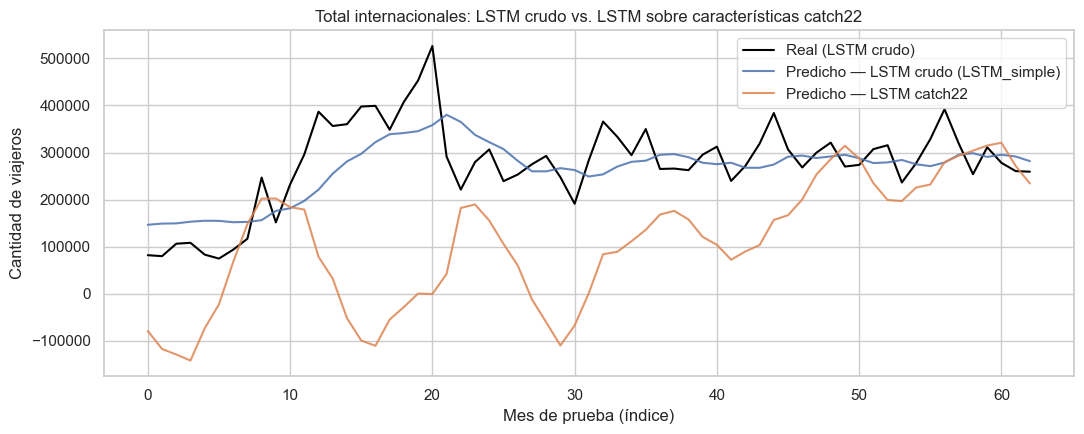

In [26]:
plt.figure(figsize=(11, 4.5))
plt.plot(mejor_raw["y_test"], label="Real (LSTM crudo)", color="black", linewidth=1.5)
plt.plot(mejor_raw["y_pred"], label=f"Predicho — LSTM crudo ({mejor_raw['arch']})", alpha=0.85)
offset = len(mejor_raw["y_test"]) - len(y_test_c22_orig)
x_c22 = np.arange(offset, offset + len(y_test_c22_orig))
plt.plot(x_c22, y_pred_c22_orig, label="Predicho — LSTM catch22", alpha=0.85)
plt.title(f"{serie_c22_name}: LSTM crudo vs. LSTM sobre características catch22")
plt.xlabel("Mes de prueba (índice)")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.tight_layout()
plt.show()


**Discusión 2.14.**

| Modelo | RMSE | MAE | MAPE |
|---|---|---|---|
| Mejor LSTM crudo (LSTM_simple, window=6) | 65,424 | 53,203 | 23.2 % |
| LSTM sobre características catch22 (window=12, seq_len=6) | 223,263 | 175,537 | 69.2 % |

El LSTM construido sobre características catch22 tiene un desempeño **notablemente peor** que el
mejor LSTM sobre valores crudos para "Total internacionales": el RMSE es 3.4 veces más alto y el MAPE
pasa de 23.2 % a 69.2 %. Esto es coherente con la naturaleza de catch22: sus 22 características fueron
diseñadas para **caracterizar y discriminar la forma/dinámica** de una serie (útiles para PCA,
clustering y distancias, como en el Ejercicio 2), no para preservar la información numérica de nivel y
tendencia necesaria para reconstruir un valor futuro preciso. Al resumir cada ventana cruda de 12
meses en 22 estadísticos (muchos de ellos adimensionales o normalizados, como medidas de entropía,
periodicidad o autocorrelación), se descarta gran parte de la magnitud real de la serie; el LSTM sobre
catch22 termina prediciendo razonablemente la *forma* del comportamiento pero con errores de nivel
mucho mayores. A esto se suma que el enfoque catch22 necesita más historia mínima
(`CATCH22_WINDOW + SEQ_LEN` = 18 meses) antes de la primera predicción posible, y opera sobre muchas
menos secuencias de entrenamiento "informativas" que el enfoque de valores crudos.

**Conclusión:** para el objetivo de *predicción puntual* (forecasting), un LSTM sobre los valores
crudos de la serie sigue siendo muy superior a un LSTM sobre características catch22. catch22 aporta
valor donde ya se usó en el Ejercicio 2 — comparar, agrupar y explicar la *similitud entre series* —
pero no es un buen sustituto de los valores originales cuando el objetivo es predecir el nivel futuro
de una sola serie con precisión.